In [6]:
import json
from pprint import pprint
from IPython.display import display, HTML, IFrame
from requests import Session


# Link to FBI swagger: https://crime-data-explorer.fr.cloud.gov/proxy/swagger-ui.html#!/victim45tkm45controller/getAgencyVictimCountsUsingGET_1
# FBI website: https://crime-data-explorer.fr.cloud.gov/api


# Base url for requests: https://api.usa.gov/crime/fbi/sapi/
ROOT = 'https://api.usa.gov/crime/fbi/sapi/'
API_KEY = 'kjnpGNxo0EyroGFmuXxOEmMq84ZkylLbDCA6NrdE&location=Denver+CO'

# ORI codes: https://www.icpsr.umich.edu/files/NACJD/ORIs/16oris.html#16_ADA_(FIPS=001_UCR=000)
display(HTML("""<h3><a name="16_ADA_(FIPS=001_UCR=001)">ADA (FIPS=001 UCR=001), ID:</a></h3>
<pre>CITY/AGENCY                                               ORI7      ORI9       

ADA COUNTY SHERIFF'S OFFICE                               ID00100   ID0010000  
BOISE POLICE DEPARTMENT                                   ID00101   ID0010100  
GARDEN CITY POLICE DEPARTMENT                             ID00102   ID0010200  
KUNA PD                                                   ID00107   ID0010700  
MERIDIAN POLICE DEPARTMENT                                ID00103   ID0010300  
</pre>
<h3><a name="16_ADA_(FIPS=001_UCR=000)">ADA (FIPS=001 UCR=000), ID:</a></h3>
<pre>CITY/AGENCY                                               ORI7      ORI9       

DLE ALCOHOL BEVERAGE CONTROL DIV BOISE                    IDDLE04   IDDLE0400  
DLE BUREAU OF NARCOTICS REGION III BOISE                  IDIBN03   IDIBN0300  
IDAHO STATE POLICE                                        IDISP00   IDISP0000  
STATE POLICE MERIDIAN                                     IDISP03   IDISP0300  
</pre>"""))

In [81]:
# offense-data-controller
# GET api/data/nibrs/{offense}/offense/agencies/{ori}/{variable}

# offender-data-controller
# GET api/data/nibrs/{offense}/offender/agencies/{ori}/{variable}


# WHERE ARE ALL THE DUI'S?!?!
ada_ori9_mapping = {
    'ADA COUNTY SHERIFF\'S OFFICE': 'ID0010000',
    'BOISE POLICE DEPARTMENT': 'ID0010100',
    'GARDEN CITY POLICE DEPARTMENT': 'ID0010200',
    'KUNA PD': 'ID0010700',
    'MERIDIAN POLICE DEPARTMENT': 'ID0010300'
}


offender_endpoint = ROOT + 'api/data/nibrs/murder-and-nonnegligent-manslaughter/offender/agencies/ID0010100/count?api_key=' + API_KEY 
s = Session()
r = s.get(url=offender_endpoint).json()['results']

with open('agg_assault_data.json', 'w') as fp:
    json.dump(r, fp)




In [82]:
import pandas as pd
import matplotlib.pyplot as plt


with open('agg_assault_data.json', 'r') as fp:
    data = json.load(fp)

df = pd.json_normalize(data)
print(df)
print(df.dtypes)

    count  data_year
0       2       1993
1       5       1994
2       3       1995
3       1       1996
4       5       1997
5       2       1998
6       2       1999
7       1       2000
8       2       2001
9       6       2002
10      3       2003
11      9       2005
12      5       2006
13     12       2007
14      1       2008
15      7       2009
16      3       2010
17      1       2011
18      2       2012
19      3       2013
20      7       2014
21      1       2015
22     10       2016
23      2       2017
24      1       2018
count        int64
data_year    int64
dtype: object


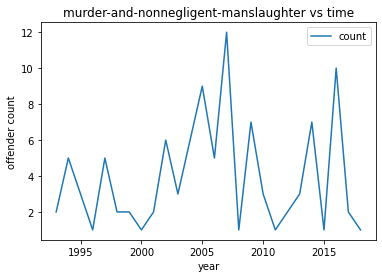

In [85]:
import matplotlib


df.plot(x='data_year', y=['count'])
# m = df.plot.scatter(x='data_year', y='male_count', color='blue')
# f = df.plot.scatter(x='data_year', y='female_count', color='grey', ax=m)
matplotlib.pyplot.ylabel('offender count')
matplotlib.pyplot.xlabel('year')
matplotlib.pyplot.title('murder-and-nonnegligent-manslaughter vs time')
plt.show()